# Greensboro Region Setup

## Stage Contract

Requires: Location config, SMART-DS AOI inputs, SFINCS/Wflow static-source settings.

Produces: Evaluation footprint, SFINCS coverage boxes, Wflow collection geometry, and static-input readiness tables.

Next: Run 02_collect_sources.ipynb to collect reviewed hydrologic source records.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

location_root = Path("..").resolve()
repo_root = location_root.parents[1]
src_root = repo_root / "src"
sys.path.insert(0, str(src_root))

# build domains, collect static inputs, and show QA plots.
import sfincs_runs.build_base.region_notebook as region

pd.set_option("display.max_colwidth", 140)

In [2]:
runtime = region.load_runtime(location_root)

pd.Series(
    {
        "location": runtime.config["project"]["place_name"],
        "selected_sfincs_domain_ids": runtime.sfincs_config["sfincs_domain_set"]["include_domain_ids"],
        "source_record_syntax": 'location_root / "data" / "sources" / "..."',
        "static_record_syntax": 'location_root / "data" / "static" / "..."',
    },
    name="region_setup_parameters",
)

location                                             Greensboro, NC, USA
selected_sfincs_domain_ids                            [greensboro_rural]
source_record_syntax          location_root / "data" / "sources" / "..."
static_record_syntax           location_root / "data" / "static" / "..."
Name: region_setup_parameters, dtype: object

## SMART-DS AOI and Evaluation Footprint


study_area                          locations/greensboro/data/static/aoi/study_area.geojson
evaluation_footprint      locations/greensboro/data/static/aoi/evaluation_footprint.geojson
source_format                                                            smart_ds_buscoords
subregion_count                                                                           3
bounds                                       (-80.000318, 35.998364, -79.499513, 36.304693)
minimum_flood_coverage                                                                 True
Name: smart_ds_aoi, dtype: object

selected_sfincs_domain_ids                                                         greensboro_rural
sfincs_coverage                                   locations/greensboro/data/static/aoi/bbox.geojson
wflow_huc_watersheds          locations/greensboro/data/static/aoi/wflow_nhdplus_watersheds.geojson
wflow_collection_boundary      locations/greensboro/data/static/aoi/wflow_collection_region.geojson
wbd_service                        https://hydro.nationalmap.gov/arcgis/rest/services/wbd/MapServer
huc_level                                                                                         8
huc_kind                                                                                      union
Name: selected_inland_region_domains, dtype: str

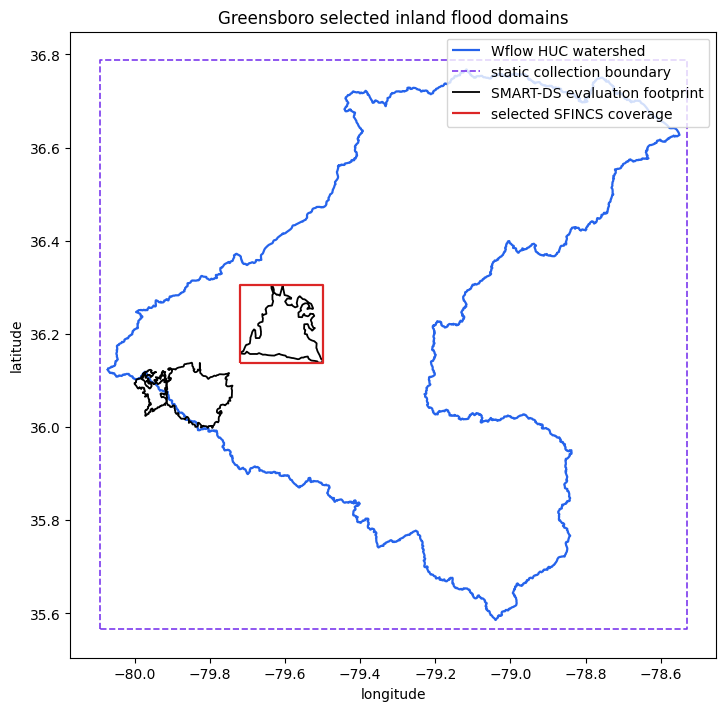

In [3]:
domains = region.build_domains(runtime)

display(domains.footprint.summary)
display(domains.summary)
region.plot_domains(runtime, domains)
plt.show()

## SFINCS and Wflow Terrain/Landcover Inputs

In [4]:
static_data = region.collect_static(runtime)  # collect_required_inland_static_data(runtime)

display(static_data.wflow_summary)
static_data.sfincs_summary

dem                            /home/grahamhults/projects/Flood-RM/locations/greensboro/data/wflow/static/processed/dem_wflow_coarse.tif
landcover                /home/grahamhults/projects/Flood-RM/locations/greensboro/data/wflow/static/processed/landcover_wflow_coarse.tif
dem_pixels                                                                                                                       2229480
landcover_pixels                                                                                                                 2229480
ssurgo_polygons                                                                                                                   184212
ssurgo_attribute_rows                                                                                                               6680
soil_mukeys                                                                                                                         1386
hsg                                      

dem                            /home/grahamhults/projects/Flood-RM/locations/greensboro/data/static/processed/dem_region_setup.tif
landcover                /home/grahamhults/projects/Flood-RM/locations/greensboro/data/static/processed/landcover_region_setup.tif
dem_pixels                                                                                                                 4250472
landcover_pixels                                                                                                           4250472
ssurgo_polygons                                                                                                              19261
ssurgo_attribute_rows                                                                                                         1182
soil_mukeys                                                                                                                    257
hsg                                  /home/grahamhults/projects/Flood-RM/locations/

## Greensboro Region Setup


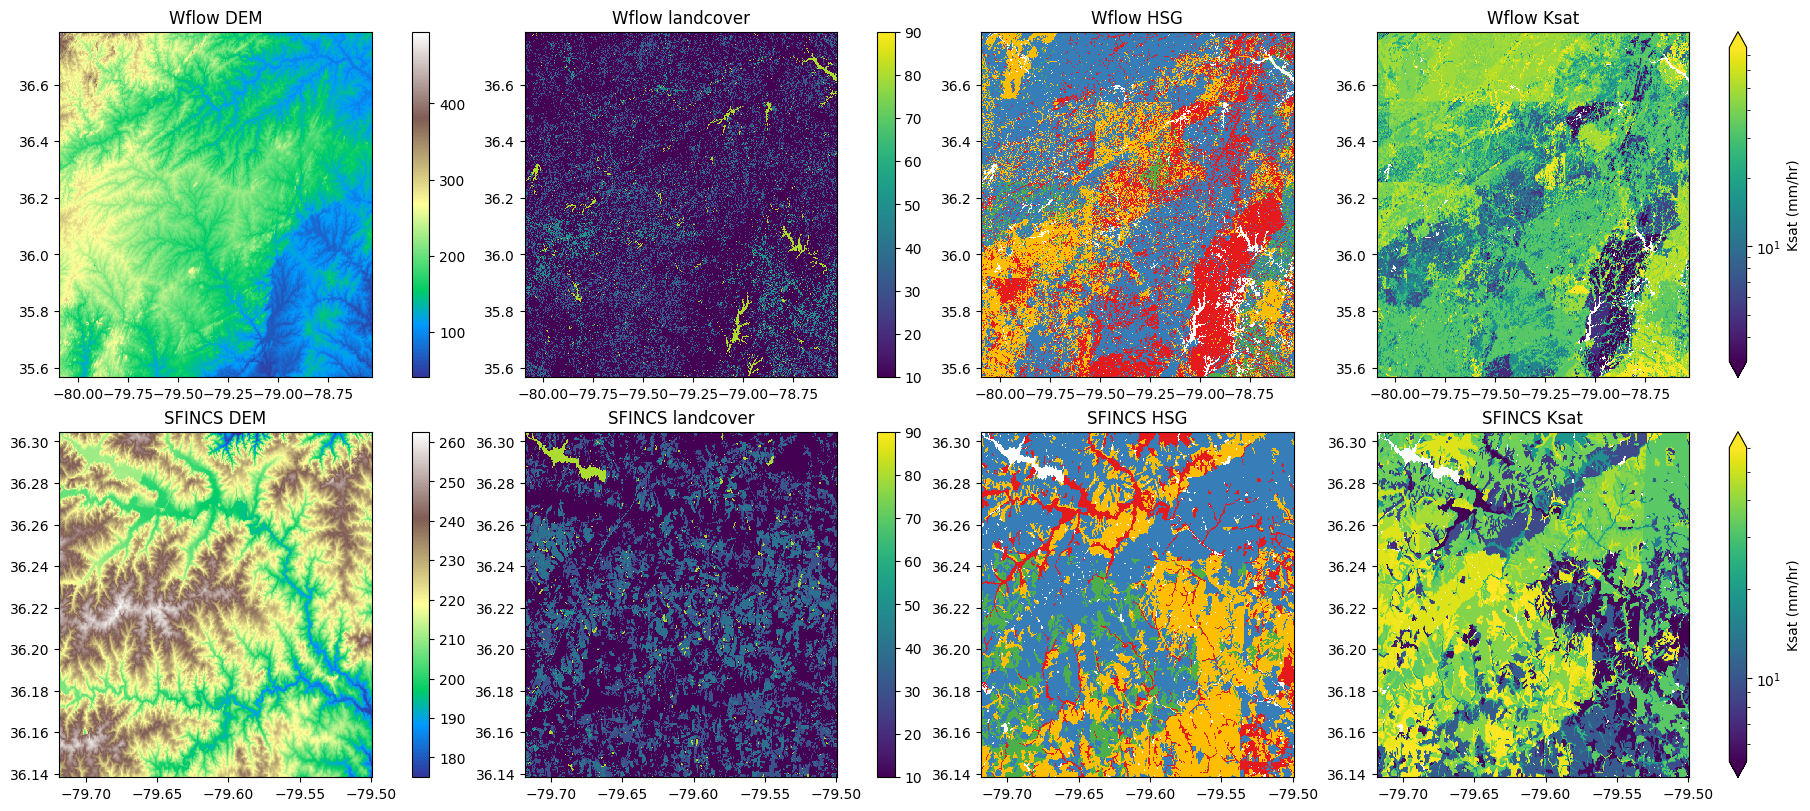

In [5]:
static_plot = region.plot_static(runtime)
if isinstance(static_plot, pd.DataFrame):
    display(static_plot)
else:
    plt.show()